In [ ]:
import importlib
importlib.reload(importlib.import_module("nlp_extract_characters"))
importlib.reload(importlib.import_module("nlp_utils"))
importlib.reload(importlib.import_module("nlp_aliases"))
importlib.reload(importlib.import_module("nlp_cooccurrence"))
importlib.reload(importlib.import_module("nlp_graph"))
importlib.reload(importlib.import_module("nlp_visualize_web"))
importlib.reload(importlib.import_module("nlp_create_submission"))
importlib.reload(importlib.import_module("nlp_multi_ner"))
from nlp_multi_ner import ensemble_entities
from nlp_create_submission import process_chapter, generate_submission
from nlp_visualize_web import create_interactive_graph
from nlp_graph import generate_graph, save_graphml, visualize_graph
from nlp_cooccurrence import detect_cooccurrences
from nlp_extract_characters import is_valid_entity, extract_entities, count_entities, filter_persons, filter_locations
from nlp_utils import read_file, load_anti_dict
from nlp_aliases import group_aliases, alias_dictionary, merge_alias_counts

import networkx as nx

/media/lotfi/Datum/M1/AMS Projet 1/FinalProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-12 15:56:52 INFO: Downloaded file to /home/lotfi/stanza_resources/resources.json
2025-12-12 15:56:52 INFO: Downloading default packages for language: fr (French) ...
2025-12-12 15:56:53 INFO: File exists: /home/lotfi/stanza_resources/fr/default.zip
2025-12-12 15:56:56 INFO: Finished downloading models and saved to /home/lotfi/stanza_resources
2025-12-12 15:56:56 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-12-12 15:56:57 INFO: Downloaded file to /home/lotfi/stanza_resources/resources.json
2025-12-12 15:56:57 WARNING: Language fr package default

2025-12-12 15:57:28,006 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, B-PER, E-PER, S-LOC, B-MISC, I-MISC, E-MISC, S-PER, B-ORG, E-ORG, S-ORG, I-ORG, B-LOC, E-LOC, S-MISC, I-PER, I-LOC, <START>, <STOP>


2025-12-12 15:57:36 INFO: Downloaded file to /home/lotfi/stanza_resources/resources.json
2025-12-12 15:57:36 INFO: Downloading default packages for language: fr (French) ...
2025-12-12 15:57:40 INFO: File exists: /home/lotfi/stanza_resources/fr/default.zip
2025-12-12 15:57:44 INFO: Finished downloading models and saved to /home/lotfi/stanza_resources
2025-12-12 15:57:44 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-12-12 15:57:44 INFO: Downloaded file to /home/lotfi/stanza_resources/resources.json
2025-12-12 15:57:44 WARNING: Language fr package default expects mwt, which has been added
2025-12-12 15:57:45 INFO: Loading these models for language: fr (French):
| Processor | Package            |
----------------------------------
| tokenize  | combined           |
| mwt       | combined           |
| ner       | wikinergold_charlm |

202

2025-12-12 15:58:16,720 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, B-PER, E-PER, S-LOC, B-MISC, I-MISC, E-MISC, S-PER, B-ORG, E-ORG, S-ORG, I-ORG, B-LOC, E-LOC, S-MISC, I-PER, I-LOC, <START>, <STOP>


2025-12-12 15:58:31 INFO: Downloaded file to /home/lotfi/stanza_resources/resources.json
2025-12-12 15:58:31 INFO: Downloading default packages for language: fr (French) ...
2025-12-12 15:58:35 INFO: File exists: /home/lotfi/stanza_resources/fr/default.zip
2025-12-12 15:58:39 INFO: Finished downloading models and saved to /home/lotfi/stanza_resources
2025-12-12 15:58:39 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-12-12 15:58:39 INFO: Downloaded file to /home/lotfi/stanza_resources/resources.json
2025-12-12 15:58:39 WARNING: Language fr package default expects mwt, which has been added
2025-12-12 15:58:39 INFO: Loading these models for language: fr (French):
| Processor | Package            |
----------------------------------
| tokenize  | combined           |
| mwt       | combined           |
| ner       | wikinergold_charlm |

202

In [28]:
print(is_valid_entity("Paris?"))
print(is_valid_entity("ONU"))
print(is_valid_entity("A"))
print(is_valid_entity("Jean-Luc"))


False
False
False
False


In [29]:
texte = read_file("output.txt")

In [ ]:
# 1. Extract ALL entities (raw)
# raw_entities = extract_entities(texte)
raw_entities = ensemble_entities(texte, method="vote")

In [23]:
# 2. Count all entities → L
L = count_entities(raw_entities)

In [24]:
anti_dict = load_anti_dict("antidict.txt")
print(anti_dict)

{'façon', 'peu', 'sois', 'dernières', 'voulussiez', 'était', 'pussent', 'autres', 'feras', 'feront', 'vraisemblablement', 'sienne', 'susdits', 'deux', 'et_al', 'quoique', 'ai', 'chapitre', 'tiennes', 'totalement', 'dès', 'pusse', 'aussi', 'voilà', 'grâce', 'l', 'voulut', 'pour', 'vouliez', 'fassions', 'actuellement', 'pourrons', 'ici', 'paf', 'priori', 'pouvons', 'voudront', 'moi', 'dedans', 'petits', 'serait', 'tous', 'évidemment', 'seulement', 'actuels', 'faisais', 'auront', 'sera', 'contrairement', 'quoiqu', 'ayantes', 'loin', 'ne', 'tantôt', 'faisait', 'devez', 'furent', 'faisant', 'aient', 'respectivement', 'voulusses', 'pouah', 'presqu', 'vos', 'pûmes', 'voulurent', 'pouvait', 'faisons', 'hein', 'hier', 'patatras', 'subit', 'où', 'dussions', 'pst', 'envers', 'avions', 'ledit', 'aurai', 'voulûmes', 'nôtre', 'bah', 'jusque', 'ma', 'voulons', 'maint', 'grand', 'hors', 'disait', 'duquel', 'pus', 'sûres', 'quel', 'sans', 'aurez', 'infiniment', 'c', 'mieux', 'dont', 'oui', 'voudrons', 

In [26]:
# 3. Extract person entities → LP
LP = filter_persons(L, anti_dict=anti_dict)

print("Person entities (raw):")
for entity, count in LP.most_common():
    print(f"{entity}: {count}")

Person entities (raw):
Trevize: 220
Gaïa: 140
Pelorat: 112
Seldon: 107
Bayta: 102
Hardin: 97
Mulet: 95
le Mulet: 92
Pritcher: 65
Hari Seldon: 62
Gaal: 55
Anthor: 55
Darell: 54
Comporellon: 54
Anacréon: 53
Bander: 48
Barr: 47
Janov: 47
Devers: 43
Riose: 41
Le Mulet: 33
Pirenne: 31
Homir: 28
Randu: 27
Munn: 26
Siwenna: 25
Trantor: 23
Marchand: 23
Tazenda: 21
docteur Darell: 21
Lepold: 20
Sermak: 18
Wienis: 18
Joie: 18
Pel: 18
Indbur: 17
Rossem: 17
Han Pritcher: 16
Maire: 15
Salvor Hardin: 14
Forell: 14
Fran: 14
Lizalor: 14
Lee: 13
Gorov: 13
Twer: 13
Monsieur: 13
Jael: 13
Ducem Barr: 13
Kalgan: 13
Deniador: 13
Kendray: 12
le Marchand: 11
Orateur: 11
Mallow: 10
Commason: 10
Premier Citoyen: 10
Kleise: 10
Dame Callia: 10
Verisof: 9
Cléon II: 8
Chen: 8
Dorwin: 8
Fara: 8
Jorane Sutt: 8
Bel Riose: 8
Toran: 8
Homir Munn: 8
Turbor: 8
Loris: 7
Jaim Twer: 7
Le Marchand: 7
Poli: 7
Papa: 7
Askone: 6
Grand Maître: 6
Hober Mallow: 6
Jord Parma: 6
Horleggor: 6
Palver: 6
Avakim: 5
Terminus: 5
Haut Rodri

In [8]:
# 4. Extract location entities → LL
LL = filter_locations(L)

In [9]:
# Write L
with open("L.txt", "w", encoding="utf8") as f:
    for (text, label), count in L.most_common():
        f.write(f"{text:30}  {label:5}  {count}\n")

# Write LP (persons)
with open("LP.txt", "w", encoding="utf8") as f:
    for text, count in LP.most_common():
        f.write(f"{text:30}  {count}\n")

# Write LL (locations)
with open("LL.txt", "w", encoding="utf8") as f:
    for text, count in LL.most_common():
        f.write(f"{text:30}  {count}\n")



In [10]:
# 5. Group aliases in LP
groups = group_aliases(LP)
alias_map = alias_dictionary(groups)
LP_merged = merge_alias_counts(LP, alias_map)

In [11]:
print("\n=== ALIAS GROUPS ===")
for grp in groups:
    print(grp)


=== ALIAS GROUPS ===
['Cléon Ier']
['Seldon', 'Hari Seldon']
['Écœurant']
['Alem']
['Hummin']
['Trantorien']
['Héliconien']
['Anacréon']
['l’Empereur']
['Demerzel']
['avisiez']
['Trantor']


In [12]:
print("\n=== ALIAS MAP ===")
for alias, canonical in alias_map.items():
    print(f"{alias:20} -> {canonical}")

print("\n=== LP MERGED ===")
for name, count in LP_merged.most_common():
    print(f"{name:30} {count}")


=== ALIAS MAP ===
Cléon Ier            -> Cléon Ier
Seldon               -> Seldon
Hari Seldon          -> Seldon
Écœurant             -> Écœurant
Alem                 -> Alem
Hummin               -> Hummin
Trantorien           -> Trantorien
Héliconien           -> Héliconien
Anacréon             -> Anacréon
l’Empereur           -> l’Empereur
Demerzel             -> Demerzel
avisiez              -> avisiez
Trantor              -> Trantor

=== LP MERGED ===
Seldon                         41
Hummin                         24
Alem                           11
Trantorien                     4
l’Empereur                     4
Demerzel                       3
Cléon Ier                      1
Écœurant                       1
Héliconien                     1
Anacréon                       1
avisiez                        1
Trantor                        1


In [13]:
cooccurrences = detect_cooccurrences(
    texte, 
    LP_merged,  # Your merged character list
    distance_max=25  # Words within 25 tokens
)

print("\n=== CO-OCCURRENCES ===")
for (char1, char2), count in cooccurrences.most_common(20):
    print(f"{char1:20} <-> {char2:20} : {count}")


=== CO-OCCURRENCES ===
Hummin               <-> Seldon               : 19
Alem                 <-> Hummin               : 9
Seldon               <-> Trantor              : 8
Alem                 <-> Seldon               : 7
Alem                 <-> Trantor              : 6
Trantor              <-> Trantorien           : 6
Seldon               <-> Trantorien           : 4
Alem                 <-> Trantorien           : 3
Demerzel             <-> Seldon               : 2
Hummin               <-> Trantorien           : 2
Hummin               <-> Trantor              : 2
Héliconien           <-> Seldon               : 1
Seldon               <-> l’Empereur           : 1
Alem                 <-> Héliconien           : 1
Alem                 <-> Demerzel             : 1
Hummin               <-> Héliconien           : 1
Hummin               <-> l’Empereur           : 1
Demerzel             <-> Héliconien           : 1
Demerzel             <-> l’Empereur           : 1
Demerzel             <-> 

✓ Graph saved to character_network.graphml


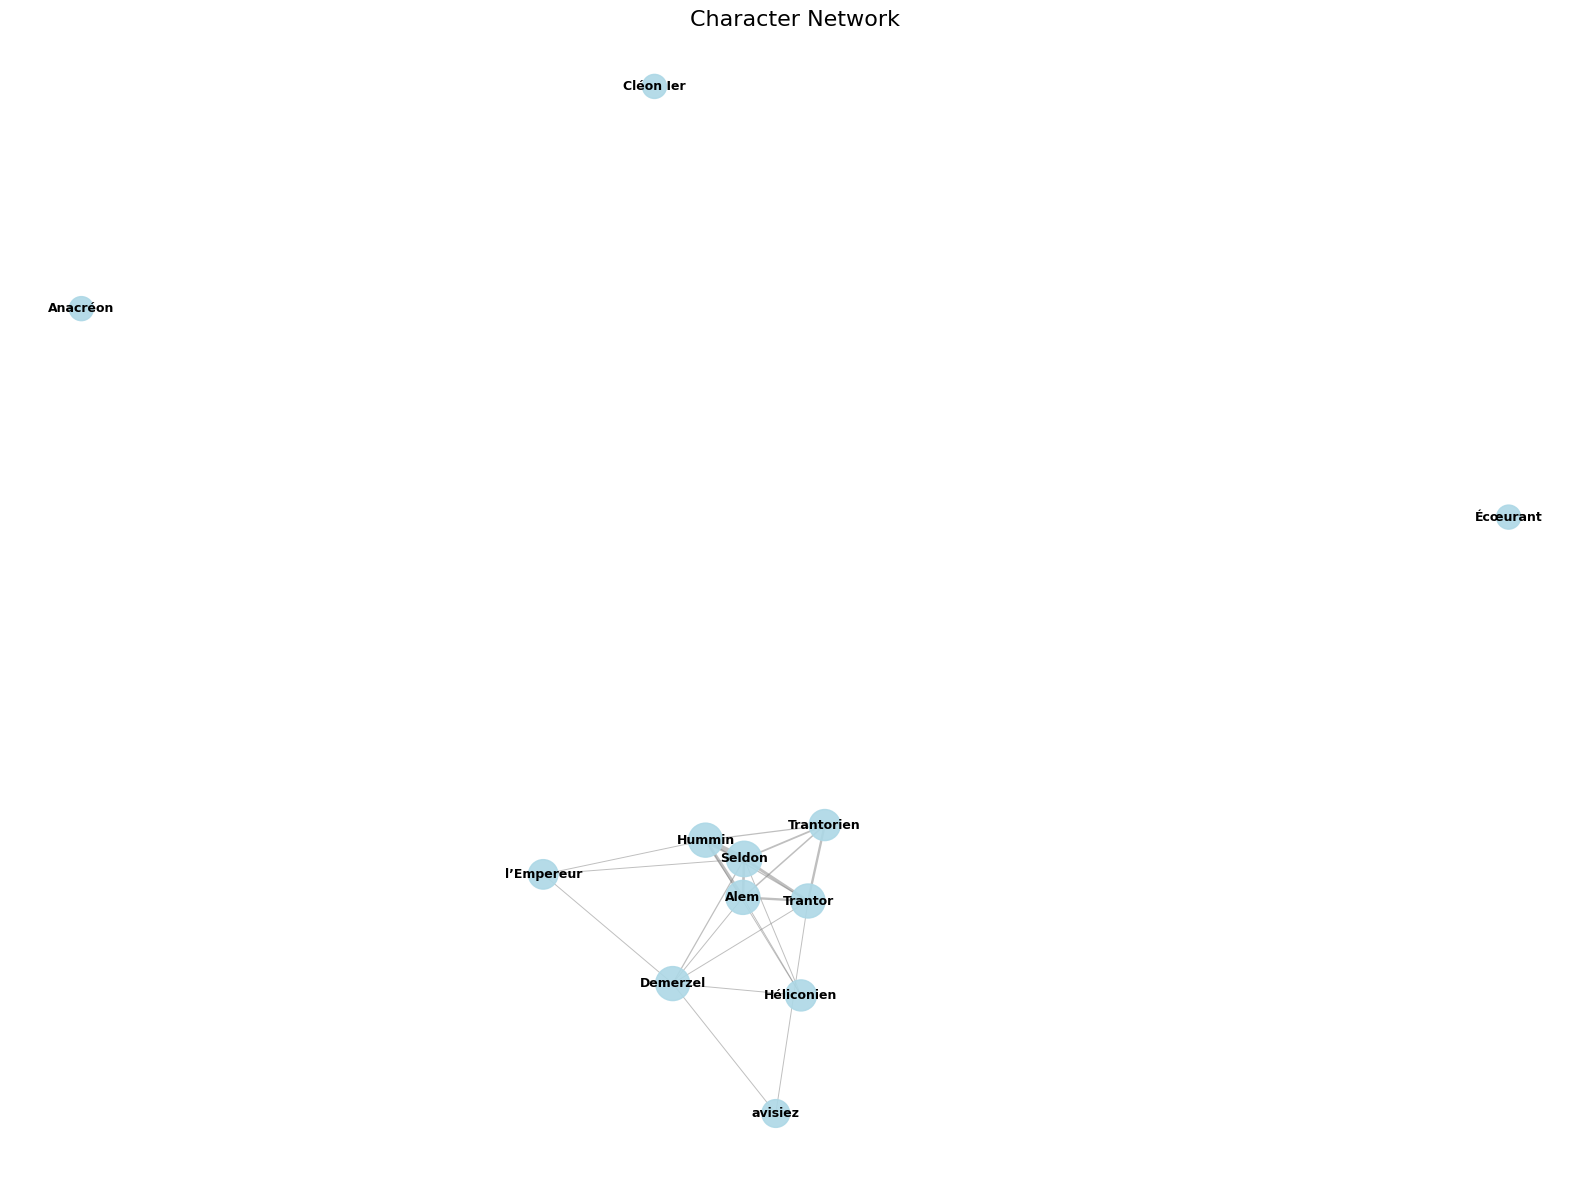

In [14]:
# Generate NetworkX graph
G = generate_graph(cooccurrences, LP_merged)

# Save as GraphML
save_graphml(G, "character_network.graphml")

# Visualize
visualize_graph(G, title="Character Network")

In [15]:
# %%
create_interactive_graph(
    G, 
    cooccurrences,
    output_file="character_network_interactive.html"
)

✓ Interactive graph saved to character_network_interactive.html


In [ ]:
# # %%
# # =============================================================================
# # CONFIGURATION - ADJUST THESE PATHS
# # =============================================================================

# books_config = [
#     # (chapter_range, book_code, folder_path)
#     (list(range(0, 19)), "paf", "data/prelude_a_fondation"),      # paf0 to paf18
#     (list(range(0, 18)), "lca", "data/les_cavernes_d_acier"),     # lca0 to lca17
# ]

# anti_dict_file = "antidict.txt"
# output_csv = "submission.csv"
# distance_max = 25  # Co-occurrence window size

# # %%
# # =============================================================================
# # RUN SUBMISSION GENERATION
# # =============================================================================

# print("🚀 Starting submission generation...")
# print(f"Distance threshold: {distance_max} words")

# df_submission = generate_submission(
#     books_config=books_config,
#     anti_dict_file=anti_dict_file,
#     output_csv=output_csv,
#     distance_max=distance_max
# )

# # %%
# # =============================================================================
# # VERIFY SUBMISSION
# # =============================================================================

# print("\n" + "="*60)
# print("SUBMISSION VERIFICATION")
# print("="*60)

# print("\n📊 Submission Overview:")
# print(df_submission.head(10))

# print("\n📈 Statistics:")
# print(f"Total entries: {len(df_submission)}")
# print(f"Expected: 37 chapters (19 paf + 18 lca)")

# # Check for missing chapters
# expected_ids = [f"paf{i}" for i in range(19)] + [f"lca{i}" for i in range(18)]
# actual_ids = set(df_submission.index)
# missing_ids = [id for id in expected_ids if id not in actual_ids]

# if missing_ids:
#     print(f"\n⚠️  Missing chapters: {', '.join(missing_ids)}")
# else:
#     print("\n✅ All expected chapters present!")

# # %%
# # =============================================================================
# # INSPECT SAMPLE GRAPHS
# # =============================================================================

# print("\n" + "="*60)
# print("SAMPLE GRAPH INSPECTION")
# print("="*60)

# sample_ids = ["paf0", "lca0"]

# for sample_id in sample_ids:
#     if sample_id in df_submission.index:
#         print(f"\n📖 Sample: {sample_id}")
        
#         # Parse GraphML back to NetworkX
#         import io
#         graphml_str = df_submission.loc[sample_id, "graphml"]
#         G_sample = nx.read_graphml(io.StringIO(graphml_str))
        
#         print(f"   Nodes: {G_sample.number_of_nodes()}")
#         print(f"   Edges: {G_sample.number_of_edges()}")
        
#         print("\n   Sample nodes with 'names' attribute:")
#         for i, (node, data) in enumerate(G_sample.nodes(data=True)):
#             if i < 5:
#                 names = data.get('names', '⚠️ MISSING')
#                 print(f"      • {node}: {names}")
#             if i == 5:
#                 print(f"      ... and {G_sample.number_of_nodes() - 5} more")
#                 break

🚀 Starting submission generation...
Distance threshold: 25 words
📚 Loading anti-dictionary from: antidict.txt
   ✓ Loaded 702 entries

📖 Processing book: paf (19 chapters)
   📄 Processing paf0... 

[1127/085845.118009:WARNING:chrome/app/chrome_main_linux.cc:82] Read channel stable from /app/extra/CHROME_VERSION_EXTRA


[1127/085845.693772:WARNING:chrome/app/chrome_main_linux.cc:82] Read channel stable from /app/extra/CHROME_VERSION_EXTRA
✓ (Nodes: 9, Edges: 10)
   📄 Processing paf1... 

Created TensorFlow Lite XNNPACK delegate for CPU.
[2:44:1127/085849.955257:ERROR:google_apis/gcm/engine/registration_request.cc:292] Registration response error message: DEPRECATED_ENDPOINT


✓ (Nodes: 12, Edges: 22)
   📄 Processing paf2... ✓ (Nodes: 6, Edges: 4)
   📄 Processing paf3... ✓ (Nodes: 13, Edges: 14)
   📄 Processing paf4... ✓ (Nodes: 11, Edges: 12)
   📄 Processing paf5... ✓ (Nodes: 10, Edges: 7)
   📄 Processing paf6... ✓ (Nodes: 18, Edges: 47)
   📄 Processing paf7... ✓ (Nodes: 13, Edges: 9)
   📄 Processing paf8... ✓ (Nodes: 10, Edges: 8)
   📄 Processing paf9... ✓ (Nodes: 8, Edges: 2)
   📄 Processing paf10... ✓ (Nodes: 17, Edges: 25)
   📄 Processing paf11... ✓ (Nodes: 13, Edges: 18)
   📄 Processing paf12... ✓ (Nodes: 23, Edges: 55)
   📄 Processing paf13... ✓ (Nodes: 18, Edges: 14)
   📄 Processing paf14... ✓ (Nodes: 14, Edges: 8)
   📄 Processing paf15... ✓ (Nodes: 18, Edges: 25)
   📄 Processing paf16... ✓ (Nodes: 22, Edges: 61)
   📄 Processing paf17... ✓ (Nodes: 19, Edges: 34)
   📄 Processing paf18... ✓ (Nodes: 15, Edges: 11)

📖 Processing book: lca (18 chapters)
   📄 Processing lca0... ✓ (Nodes: 11, Edges: 8)
   📄 Processing lca1... ✓ (Nodes: 6, Edges: 4)
   📄 Pro

In [17]:

# %%
# =============================================================================
# VALIDATE GRAPHML FORMAT
# =============================================================================

print("\n" + "="*60)
print("GRAPHML FORMAT VALIDATION")
print("="*60)

# Check if all graphs can be parsed
errors = []
for idx in df_submission.index:
    try:
        graphml_str = df_submission.loc[idx, "graphml"]
        G_test = nx.read_graphml(io.StringIO(graphml_str))
        
        # Check that all nodes have 'names' attribute
        for node in G_test.nodes():
            if "names" not in G_test.nodes[node]:
                errors.append(f"{idx}: Node '{node}' missing 'names' attribute")
    except Exception as e:
        errors.append(f"{idx}: GraphML parse error: {e}")

if errors:
    print("⚠️  Validation errors found:")
    for error in errors[:10]:  # Show first 10
        print(f"   • {error}")
    if len(errors) > 10:
        print(f"   ... and {len(errors) - 10} more errors")
else:
    print("✅ All graphs valid! Ready for submission.")

print("\n" + "="*60)
print(f"🎯 FINAL OUTPUT: {output_csv}")
print("="*60)


GRAPHML FORMAT VALIDATION
✅ All graphs valid! Ready for submission.

🎯 FINAL OUTPUT: submission.csv
